# 05 — Learning the model with Expectation–Maximization, from scratch

This notebook answers the question Marc posed:

> *"We use the BP algorithm but don't give it the $P_0$ parameters (e.g. the transition kernel
> $K_i$), meaning that we know the data is Markov + noise but we don't know exactly the model
> behind. Then, starting from a random initialization, we iterate following the gradient of the
> loss constructed from the likelihood function along the direction of the parameters, evaluated
> on a finite number of datapoints."*

Everything here is written from scratch in plain `numpy` — about 120 lines in total. Nothing is
imported from `src/`. That is deliberate: the point is to *see* the mechanism, and a notebook that
calls `fit_em()` teaches nothing. At the very end we check our from-scratch code against the
repository's tested implementation, so the notebook validates itself rather than asking you to
trust it.

The other notebooks in this directory (`01`–`04`) report committed results. This one is a
tutorial and computes everything live, in about three minutes.

**The ladder we climb.**

| step | what is unknown | what we learn |
|---|---|---|
| 0 | nothing | check that belief propagation is exact here |
| 1 | one number, $\rho$ | EM with a closed-form M-step |
| 1b | — | Marc's literal route: gradient ascent via Fisher's identity |
| 2 | the whole innovation density | a mixture kernel recovers a Laplace it has never seen |
| 3 | — | the learned kernel gives the denoiser at *every* noise level, for free |
| 4 | — | a warning: the coordinates converge at wildly different speeds |

## The model

A latent first-order Markov chain of length $n$ on the real line,

$$a_1 \sim \mathcal N(0,1), \qquad a_i = \rho\,a_{i-1} + \varepsilon_i, \qquad \varepsilon_i \sim \varphi ,$$

with $|\rho| < 1$ and $\varphi$ some innovation density. We never see $a$. We see it through a
coordinatewise Ornstein–Uhlenbeck channel at a known noise level $t$ — exactly the forward process
of a diffusion model:

$$x = \alpha_t\, a + \sqrt{\Delta_t}\, z, \qquad z\sim\mathcal N(0,I), \qquad
\alpha_t = e^{-t}, \quad \Delta_t = 1-e^{-2t}.$$

Choosing $\varphi$ with variance $q = 1-\rho^2$ makes the chain stationary with unit marginal
variance, which keeps every scale comparable as $\rho$ changes.

Our job: recover $\rho$ and $\varphi$ from the $x$'s alone.

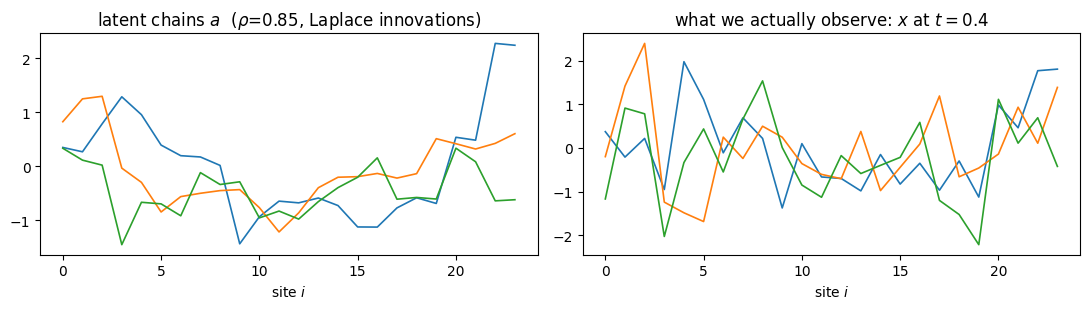

marginal variance of a: 1.028  (stationary target 1.0)
innovation excess kurtosis, true Laplace: 3.0


In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng_global = np.random.default_rng(0)

def alpha_delta(t):
    "OU channel coefficients."
    return float(np.exp(-t)), float(1.0 - np.exp(-2.0 * t))

def sample_chains(rho, n_chains, n_sites, innovation, rng):
    "Draw chains from a stationary AR(1) with the given innovation sampler."
    q = 1.0 - rho ** 2
    A = np.empty((n_chains, n_sites))
    A[:, 0] = rng.standard_normal(n_chains)            # stationary: N(0, 1)
    for i in range(1, n_sites):
        A[:, i] = rho * A[:, i - 1] + innovation(q, n_chains, rng)
    return A

def gaussian_innov(q, size, rng):
    return np.sqrt(q) * rng.standard_normal(size)

def laplace_innov(q, size, rng):
    "Laplace with variance q; excess kurtosis 3 regardless of q."
    return rng.laplace(0.0, np.sqrt(q / 2.0), size)

def noise(A, t, rng):
    a, d = alpha_delta(t)
    return a * A + np.sqrt(d) * rng.standard_normal(A.shape)

RHO_TRUE, N_SITES, N_CHAINS = 0.85, 24, 256
A_lap = sample_chains(RHO_TRUE, N_CHAINS, N_SITES, laplace_innov, np.random.default_rng(1))
X_demo = noise(A_lap, 0.4, np.random.default_rng(2))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
for r in range(3):
    ax[0].plot(A_lap[r], lw=1.2)
    ax[1].plot(X_demo[r], lw=1.2)
ax[0].set_title(f"latent chains $a$  ($\\rho$={RHO_TRUE}, Laplace innovations)")
ax[1].set_title("what we actually observe: $x$ at $t=0.4$")
for a_ in ax: a_.set_xlabel("site $i$")
plt.tight_layout(); plt.show()

print(f"marginal variance of a: {A_lap.var():.3f}  (stationary target 1.0)")
print(f"innovation excess kurtosis, true Laplace: 3.0")

## Step 0 — the one idea: the noised posterior is *still a chain*

This is the whole reason any of this works, and it is worth stating carefully.

The prior factorises along a chain, and the channel acts on each coordinate **separately**:

$$p(a \mid x) \;\propto\; \underbrace{p(a_1)\prod_{i\ge 2} K(a_i \mid a_{i-1})}_{\text{chain prior}}
\;\times\; \underbrace{\prod_{i} \mathcal N\!\big(x_i;\, \alpha_t a_i,\, \Delta_t\big)}_{\text{one factor per site}} .$$

The likelihood contributes **one unary factor per site and no new edges**. So the posterior is a
chain with the same edges as the prior — a tree. On a tree, sum–product (belief propagation) is
*exact*: it is not an approximation we hope is good, it is the answer.

That gives us two things at once:

* the **exact marginal likelihood** $\log p_t(x)$ of the observed data, which is the objective EM
  needs, and
* the **exact pairwise posteriors** $\Xi$, which are the sufficient statistics the M-step needs.

We discretise $a$ on a grid $u_1,\dots,u_M \in [-A, A]$ and integrate with the trapezoid rule, so
"exact" means exact up to quadrature and truncation — both of which we can check by refining.

In [2]:
def make_grid(half_width, n_points):
    grid = np.linspace(-half_width, half_width, n_points)
    h = grid[1] - grid[0]
    w = np.full(n_points, h)
    w[0] *= 0.5; w[-1] *= 0.5                  # trapezoid weights
    return grid, w

def log_K_gaussian(rho, q, grid):
    "log K[k, j] = log N(u_k - rho*u_j; 0, q).  Rows = destination, columns = source."
    e = grid[:, None] - rho * grid[None, :]
    return -0.5 * np.log(2 * np.pi * q) - e ** 2 / (2 * q)

def log_unary(X, t, grid):
    "log N(x_i; alpha*u_k, delta) for every chain, site and grid point -> (n, T, M)."
    a, d = alpha_delta(t)
    r = X[:, :, None] - a * grid[None, None, :]
    return -0.5 * np.log(2 * np.pi * d) - r ** 2 / (2 * d)

def log_prior_site1(grid):
    "a_1 ~ N(0, 1): the stationary marginal, treated as known."
    return -0.5 * np.log(2 * np.pi) - grid ** 2 / 2

### Belief propagation on the chain

Forward–backward, with the messages renormalised at every step so nothing underflows; the
discarded normalising constants are accumulated and give the log-evidence exactly.

With `K[k, j]` $= K(u_k \mid u_j)$:

$$f_i(u_k) \;\propto\; \ell_i(u_k)\sum_j K[k,j]\, w_j\, f_{i-1}(u_j),
\qquad
b_i(u_j) \;=\; \sum_k K[k,j]\, w_k\, \ell_{i+1}(u_k)\, b_{i+1}(u_k),$$

and the pairwise posterior on edge $i$ is $\Xi_i[k,j] \propto b_{i+1}(u_k)\,\ell_{i+1}(u_k)\,w_k\,
K[k,j]\, f_i(u_j)\, w_j$. We sum $\Xi_i$ over every edge and every chain, because that sum is the
only thing the M-step will need.

In [3]:
def bp(grid, w, log_K, X, t):
    "Exact forward-backward. Returns (total log-evidence, summed pairwise posterior Xi)."
    n, T = X.shape
    M = grid.size
    K = np.exp(log_K)

    lu = log_unary(X, t, grid)                     # (n, T, M)
    lu_max = lu.max(axis=2, keepdims=True)         # pull out the scale to avoid underflow
    lik = np.exp(lu - lu_max)
    log_ev = lu_max.sum(axis=(1, 2))               # (n,) -- restored at the end

    # ---- forward
    f = np.empty((n, T, M))
    cur = np.exp(log_prior_site1(grid))[None, :] * lik[:, 0, :]
    c = (cur * w).sum(1); f[:, 0] = cur / c[:, None]; log_ev += np.log(c)
    for i in range(1, T):
        cur = ((f[:, i - 1] * w) @ K.T) * lik[:, i, :]
        c = (cur * w).sum(1); f[:, i] = cur / c[:, None]; log_ev += np.log(c)

    # ---- backward (scale is irrelevant: Xi is renormalised per edge)
    b = np.ones((n, T, M))
    for i in range(T - 2, -1, -1):
        m = (b[:, i + 1] * lik[:, i + 1] * w) @ K
        b[:, i] = m / m.max(axis=1, keepdims=True)

    # ---- pairwise posteriors, accumulated over chains and edges
    Xi = np.zeros((M, M))
    for i in range(T - 1):
        left = f[:, i, :] * w                                  # index j (source)
        right = lik[:, i + 1, :] * b[:, i + 1, :] * w           # index k (destination)
        Z = (right * (left @ K.T)).sum(1)                       # per-chain edge normaliser
        Xi += K * ((right / Z[:, None]).T @ left)
    return float(log_ev.sum()), Xi

### Does it actually compute the right thing?

An implementation that is subtly wrong will still produce plausible-looking curves, so we check it
against brute force. For a very short chain we can evaluate

$$p(x) = \int\!\!\int\!\!\int p(a_1)K(a_2|a_1)K(a_3|a_2)\prod_i \mathcal N(x_i;\alpha a_i,\Delta)\,
\mathrm d a_1 \mathrm d a_2 \mathrm d a_3$$

as a direct triple sum over the grid — $O(M^3)$, hopeless in general, fine for $n=3$.

In [4]:
g_s, w_s = make_grid(6.0, 61)
lK_s = log_K_gaussian(0.7, 1 - 0.7 ** 2, g_s)
K_s = np.exp(lK_s)
X_s = noise(sample_chains(0.7, 4, 3, gaussian_innov, np.random.default_rng(3)),
            0.5, np.random.default_rng(4))

# brute force: sum over every (a1, a2, a3) grid triple
lik_s = np.exp(log_unary(X_s, 0.5, g_s))                     # (4, 3, M)
p0 = np.exp(log_prior_site1(g_s))
brute = np.empty(4)
Kw = K_s * w_s[:, None]          # K[k, j] * w_k : carries the weight of the DESTINATION variable
for c in range(4):
    # exactly one quadrature weight per integration variable: a1 from p0*w, a2 and a3 from Kw
    tot = np.einsum("a,a,ba,b,cb,c->", p0 * w_s, lik_s[c, 0],
                    Kw, lik_s[c, 1], Kw, lik_s[c, 2])
    brute[c] = np.log(tot)

bp_total, _ = bp(g_s, w_s, lK_s, X_s, 0.5)
print(f"brute force  log p(x) summed over chains : {brute.sum():.10f}")
print(f"belief propagation, same quantity        : {bp_total:.10f}")
print(f"absolute difference                      : {abs(bp_total - brute.sum()):.3e}")
assert abs(bp_total - brute.sum()) < 1e-9, "BP does not match brute force"
print("\\nBP is exact on the chain, to floating point.")

brute force  log p(x) summed over chains : -17.8017854272
belief propagation, same quantity        : -17.8017854272
absolute difference                      : 1.066e-14
\nBP is exact on the chain, to floating point.


## Step 1 — learn a single parameter $\rho$

Now we hide $\rho$ from the algorithm. The innovation is still assumed Gaussian, so
$\theta = (\rho, q)$: two numbers.

**EM in one paragraph.** We cannot maximise $\log p_\theta(x)$ directly because the latent $a$ is
integrated out. So we alternate:

* **E-step.** At the current $\theta$, run BP to get the pairwise posterior $\Xi$ and the exact
  $\log p_\theta(x)$.
* **M-step.** Maximise $Q(\theta' \mid \theta) = \langle \Xi,\; \log K_{\theta'}\rangle$, the
  expected complete-data log-likelihood.

The guarantee is that each round cannot *decrease* $\log p_\theta(x)$, so the log-likelihood we
print must increase monotonically. It is the sharpest test of the whole pipeline: a sign error
anywhere in the recursion destroys it.

For a Gaussian innovation the M-step is closed form. Setting $\nabla_{\theta'} Q = 0$ gives
weighted Yule–Walker equations,

$$\rho = \frac{S_{01}}{S_{00}}, \qquad q = \frac{S_{11} - S_{01}^2/S_{00}}{W},$$

with $S_{ab} = \sum_{k,j}\Xi[k,j]\,u_j^{\,a} u_k^{\,b}$ and $W = \sum_{k,j}\Xi[k,j]$. Note this
reduces to ordinary least squares when the data are clean, as it must.

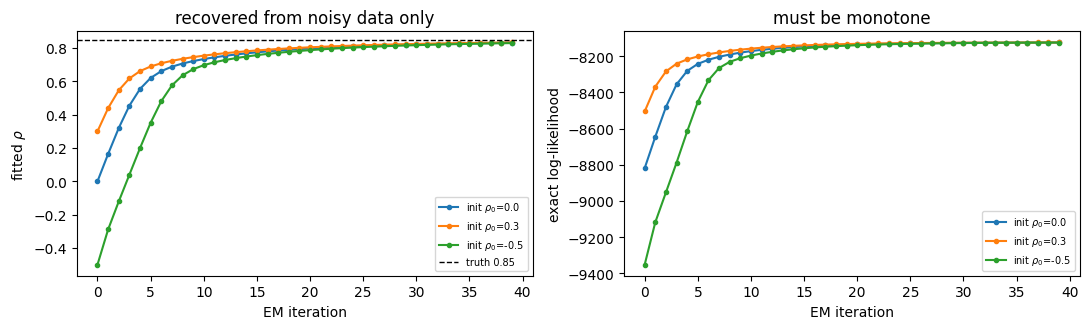

init +0.0 -> rho 0.8324, q 0.3384 (truth 0.85, 0.2775)   min LL increase +1.322e-01
init +0.3 -> rho 0.8340, q 0.3345 (truth 0.85, 0.2775)   min LL increase +1.013e-01
init -0.5 -> rho 0.8303, q 0.3438 (truth 0.85, 0.2775)   min LL increase +1.808e-01


In [5]:
def m_step_gaussian(Xi, grid):
    "Closed-form maximiser of <Xi, log K>."
    uj, uk = grid[None, :], grid[:, None]
    W   = Xi.sum()
    S00 = (Xi * uj ** 2).sum()
    S01 = (Xi * uj * uk).sum()
    S11 = (Xi * uk ** 2).sum()
    rho = S01 / S00
    q   = (S11 - S01 ** 2 / S00) / W
    return rho, max(q, 1e-6)

def em_gaussian(X, t, grid, w, rho0, q0, n_iter=40):
    # Returns the final parameters AND the (theta, log-likelihood) trace. The trace records theta
    # before each M-step, so hist[-1] is one step behind the returned (rho, q) -- keeping the two
    # separate is what lets the final cell compare exactly against the repository.
    rho, q, hist = rho0, q0, []
    for _ in range(n_iter):
        ll, Xi = bp(grid, w, log_K_gaussian(rho, q, grid), X, t)   # E-step
        hist.append((rho, q, ll))
        rho, q = m_step_gaussian(Xi, grid)                          # M-step
    return rho, q, np.array(hist)

grid, w = make_grid(8.0, 161)
A_g = sample_chains(RHO_TRUE, N_CHAINS, N_SITES, gaussian_innov, np.random.default_rng(5))
X_g = noise(A_g, 0.4, np.random.default_rng(6))

runs = {r0: em_gaussian(X_g, 0.4, grid, w, r0, 0.8) for r0 in (0.0, 0.3, -0.5)}

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for r0, (_, _, h) in runs.items():
    ax[0].plot(h[:, 0], marker="o", ms=3, label=f"init $\\rho_0$={r0}")
    ax[1].plot(h[:, 2], marker="o", ms=3, label=f"init $\\rho_0$={r0}")
ax[0].axhline(RHO_TRUE, color="k", ls="--", lw=1, label="truth 0.85")
ax[0].set_xlabel("EM iteration"); ax[0].set_ylabel(r"fitted $\rho$"); ax[0].legend(fontsize=7)
ax[0].set_title("recovered from noisy data only")
ax[1].set_xlabel("EM iteration"); ax[1].set_ylabel("exact log-likelihood")
ax[1].set_title("must be monotone"); ax[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

for r0, (rf, qf, h) in runs.items():
    print(f"init {r0:+.1f} -> rho {rf:.4f}, q {qf:.4f} "
          f"(truth {RHO_TRUE}, {1-RHO_TRUE**2:.4f})   min LL increase {np.diff(h[:,2]).min():+.3e}")

Three very different starting points — including one with the **wrong sign** — land on the same
answer, and the log-likelihood never decreases. The estimator has never seen a clean sample.

$\rho$ lands within about $0.02$ of the truth. The innovation variance $q$ comes out noticeably
high ($\approx 0.34$ against $0.2775$), and it is worth knowing which explanation is right rather
than guessing: it is **finite-sample, not the grid**. Refining the grid from $M=161$ to $321$
changes the answer in no digit at all, while raising the budget from $256$ chains to $2048$ moves
$q$ from $0.338$ to $0.311$. Blaming quadrature would have been the natural reflex and would have
been wrong.

### What does the noise cost?

The same fit at several noise levels. As $t\to 0$ the latent chain is effectively observed and EM
degenerates to ordinary least squares; as $t$ grows the channel destroys information and the
estimate degrades. This is the "price of noising".

In [6]:
print(f"{'t':>6} {'alpha':>7} {'Delta':>7} {'fitted rho':>11} {'error':>9}")
for t in (0.1, 0.4, 0.8, 1.6):
    Xt = noise(A_g, t, np.random.default_rng(7))
    rf, _, _ = em_gaussian(Xt, t, grid, w, 0.2, 0.8, n_iter=40)
    a_, d_ = alpha_delta(t)
    print(f"{t:6.1f} {a_:7.3f} {d_:7.3f} {rf:11.4f} {rf-RHO_TRUE:+9.4f}")

     t   alpha   Delta  fitted rho     error


   0.1   0.905   0.181      0.8507   +0.0007


   0.4   0.670   0.551      0.8423   -0.0077


   0.8   0.449   0.798      0.7661   -0.0839


   1.6   0.202   0.959      0.2927   -0.5573


## Step 1b — Marc's literal route: gradient ascent

Marc phrased the update as *"iterate following the gradient of the loss constructed from the
likelihood function along the direction of the parameters"*. That route is available and cheap,
because of **Fisher's identity**:

$$\nabla_\theta \log p_\theta(x) \;=\; \big\langle\, \Xi,\; \nabla_\theta \log K_\theta \,\big\rangle .$$

The gradient of the *exact marginal* likelihood is just the same $\Xi$ from the same BP pass,
contracted against the derivative of the kernel. **No differentiation through the recursion is
needed** — no autodiff, no unrolling. One E-step gives you both the EM update and the gradient.

Below we verify the identity numerically against finite differences, then compare the two routes.

Fisher's identity check
  analytic <Xi, grad log K> : [1026.24495396  270.17912969]
  central differences       : [1026.24495348  270.1791298 ]
  max relative error        : 4.69e-10


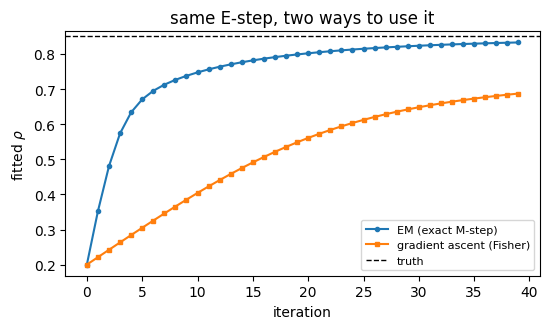

after 40 iterations:  EM rho 0.8335   gradient rho 0.6872


In [7]:
def grad_log_K_gaussian(rho, q, grid):
    "d log K / d(rho, q), stacked."
    e = grid[:, None] - rho * grid[None, :]
    return np.stack([e * grid[None, :] / q, -1.0 / (2 * q) + e ** 2 / (2 * q ** 2)])

# --- check Fisher's identity against central differences
rho_c, q_c = 0.6, 0.5
ll_c, Xi_c = bp(grid, w, log_K_gaussian(rho_c, q_c, grid), X_g, 0.4)
analytic = np.einsum("pkj,kj->p", grad_log_K_gaussian(rho_c, q_c, grid), Xi_c)
numeric = []
for idx, (r_, q_) in enumerate(((rho_c, q_c), (rho_c, q_c))):
    h = 1e-5
    up = [rho_c, q_c]; dn = [rho_c, q_c]
    up[idx] += h; dn[idx] -= h
    numeric.append((bp(grid, w, log_K_gaussian(*up, grid), X_g, 0.4)[0]
                    - bp(grid, w, log_K_gaussian(*dn, grid), X_g, 0.4)[0]) / (2 * h))
numeric = np.array(numeric)
print("Fisher's identity check")
print(f"  analytic <Xi, grad log K> : {analytic}")
print(f"  central differences       : {numeric}")
print(f"  max relative error        : {np.abs(analytic/numeric - 1).max():.2e}")

# --- gradient ascent vs EM, same start
def grad_ascent(X, t, grid, w, rho0, q0, lr=2e-5, n_iter=40):
    rho, q, hist = rho0, q0, []
    for _ in range(n_iter):
        ll, Xi = bp(grid, w, log_K_gaussian(rho, q, grid), X, t)
        hist.append((rho, q, ll))
        g = np.einsum("pkj,kj->p", grad_log_K_gaussian(rho, q, grid), Xi)
        rho += lr * g[0]; q = max(q + lr * g[1], 1e-6)
    return np.array(hist)

rho_em, _, h_em = em_gaussian(X_g, 0.4, grid, w, 0.2, 0.8, n_iter=40)
h_gd = grad_ascent(X_g, 0.4, grid, w, 0.2, 0.8, n_iter=40)

plt.figure(figsize=(5.6, 3.4))
plt.plot(h_em[:, 0], marker="o", ms=3, label="EM (exact M-step)")
plt.plot(h_gd[:, 0], marker="s", ms=3, label="gradient ascent (Fisher)")
plt.axhline(RHO_TRUE, color="k", ls="--", lw=1, label="truth")
plt.xlabel("iteration"); plt.ylabel(r"fitted $\rho$"); plt.legend(fontsize=8)
plt.title("same E-step, two ways to use it"); plt.tight_layout(); plt.show()
print(f"after 40 iterations:  EM rho {rho_em:.4f}   gradient rho {h_gd[-1,0]:.4f}")

Both climb the same likelihood; the exact M-step simply takes the biggest step it can, while
gradient ascent takes the step you tell it to and needs a learning rate. Where a closed-form
M-step exists, use it. Fisher's identity matters most when it does *not* — you still get the exact
gradient from one BP pass.

## Step 2 — learn the whole kernel, not just a number

Now the harder and more interesting case, and the one Marc actually described: **we do not know
the model behind the data.** The chains are driven by *Laplace* innovations, and we fit a kernel
whose innovation density is a $C$-component Gaussian mixture:

$$\varphi_\theta(e) = \sum_{c=1}^{C} \pi_c\, \mathcal N(e;\,\mu_c,\,s_c^2),
\qquad K_\theta(a'\mid a) = \varphi_\theta(a' - \rho a).$$

The fitted family has never heard of a Laplace density. If EM recovers the right *shape*, the
method is genuinely learning the model rather than fitting a parameter we handed it.

The M-step now has its own latent variable — which mixture component produced each innovation —
so it is itself a small EM, run against the fixed $\Xi$. Both blocks are closed form:

$$\pi_c \propto \langle \Xi\, r_c\rangle,\quad
\mu_c = \frac{\langle \Xi\, r_c\, e\rangle}{\langle \Xi\, r_c\rangle},\quad
s_c^2 = \frac{\langle \Xi\, r_c\,(e-\mu_c)^2\rangle}{\langle \Xi\, r_c\rangle},$$

with responsibilities $r_c \propto \pi_c \mathcal N(e;\mu_c,s_c^2)$, followed by a weighted update
for $\rho$.

**One protocol choice, stated rather than buried.** Each chain is observed *once*, and the chains
are split evenly over five noise levels $t\in\{0.1,\dots,1.6\}$. Noising the *same* chain at five
levels and treating the results as independent would be a composite likelihood, not the marginal
likelihood of the data we actually generated. The low-$t$ chains matter here: shape information
disappears far faster with $t$ than correlation information does.

In [8]:
def log_K_mixture(rho, pi, mu, s2, grid):
    e = grid[:, None] - rho * grid[None, :]                       # (M, M)
    z = (e[None] - mu[:, None, None]) ** 2 / s2[:, None, None]
    lg = -0.5 * np.log(2 * np.pi * s2[:, None, None]) - 0.5 * z + np.log(pi[:, None, None])
    mx = lg.max(0)
    return mx + np.log(np.exp(lg - mx).sum(0))

def m_step_mixture(Xi, grid, rho, pi, mu, s2, n_inner=4):
    "Generalised M-step: an inner EM over the mixture label, against a fixed Xi."
    uj = grid[None, :]
    for _ in range(n_inner):
        e = grid[:, None] - rho * uj
        lg = (-0.5 * np.log(2 * np.pi * s2[:, None, None])
              - 0.5 * (e[None] - mu[:, None, None]) ** 2 / s2[:, None, None]
              + np.log(pi[:, None, None]))
        r = np.exp(lg - lg.max(0))
        r /= r.sum(0)                                             # responsibilities (C, M, M)
        wgt = (r * Xi).sum((1, 2))                                # mass per component
        pi = np.maximum(wgt / wgt.sum(), 1e-8)
        mu = (r * Xi * e).sum((1, 2)) / wgt
        s2 = np.maximum((r * Xi * (e - mu[:, None, None]) ** 2).sum((1, 2)) / wgt, 1e-6)
        num = (r * Xi * uj * (grid[:, None] - mu[:, None, None]) / s2[:, None, None]).sum()
        den = (r * Xi * uj ** 2 / s2[:, None, None]).sum()
        rho = num / den
    return rho, pi, mu, s2

def one_view_groups(A, t_values, rng):
    "Split the chains across noise levels: one clean chain -> one noisy observation."
    parts = np.array_split(rng.permutation(len(A)), len(t_values))
    return [(noise(A[idx], t, rng), t) for t, idx in zip(t_values, parts)]

def em_mixture(groups, grid, w, C=6, n_iter=400, seed=0):
    r = np.random.default_rng(seed)
    rho, pi = 0.3, np.full(C, 1.0 / C)
    mu = 0.3 * r.standard_normal(C)
    s2 = np.full(C, 0.8)
    hist = []
    for _ in range(n_iter):
        ll, Xi = 0.0, np.zeros((grid.size, grid.size))
        lK = log_K_mixture(rho, pi, mu, s2, grid)
        for X, t in groups:                                        # E-step over all levels
            l_, Xi_ = bp(grid, w, lK, X, t)
            ll += l_; Xi += Xi_
        hist.append((rho, ll, *innovation_moments(pi, mu, s2)))
        rho, pi, mu, s2 = m_step_mixture(Xi, grid, rho, pi, mu, s2)
    return (rho, pi, mu, s2), np.array(hist)

def innovation_moments(pi, mu, s2):
    "Variance and excess kurtosis of the fitted innovation density."
    m1 = pi @ mu
    c = mu - m1
    m2 = pi @ (s2 + c ** 2)
    m4 = pi @ (3 * s2 ** 2 + 6 * s2 * c ** 2 + c ** 4)
    return m2, m4 / m2 ** 2 - 3.0

T_TRAIN = (0.1, 0.2, 0.4, 0.8, 1.6)

# A whole density is a much harder thing to estimate than two numbers, so Step 2 gets a bigger
# sample than Steps 1 and 1b: 512 chains of 32 sites rather than 256 of 24. This matches the
# configuration used elsewhere in the repository, so the numbers below are comparable to it.
A_lap_big = sample_chains(RHO_TRUE, 512, 32, laplace_innov, np.random.default_rng(1))
groups = one_view_groups(A_lap_big, T_TRAIN, np.random.default_rng(8))
(fit_rho, fit_pi, fit_mu, fit_s2), hist_mix = em_mixture(groups, grid, w, C=8, n_iter=400)
var_hat, kurt_hat = innovation_moments(fit_pi, fit_mu, fit_s2)
print(f"fitted rho  {fit_rho:.4f}   (truth {RHO_TRUE})")
print(f"innovation variance  {var_hat:.4f}   (truth {1-RHO_TRUE**2:.4f})")
print(f"innovation excess kurtosis  {kurt_hat:.3f}   (truth 3.0 for Laplace)")
print(f"log-likelihood monotone?  min increase {np.diff(hist_mix[:,1]).min():+.3e}")

fitted rho  0.8462   (truth 0.85)
innovation variance  0.2943   (truth 0.2775)
innovation excess kurtosis  3.114   (truth 3.0 for Laplace)
log-likelihood monotone?  min increase +2.537e-03


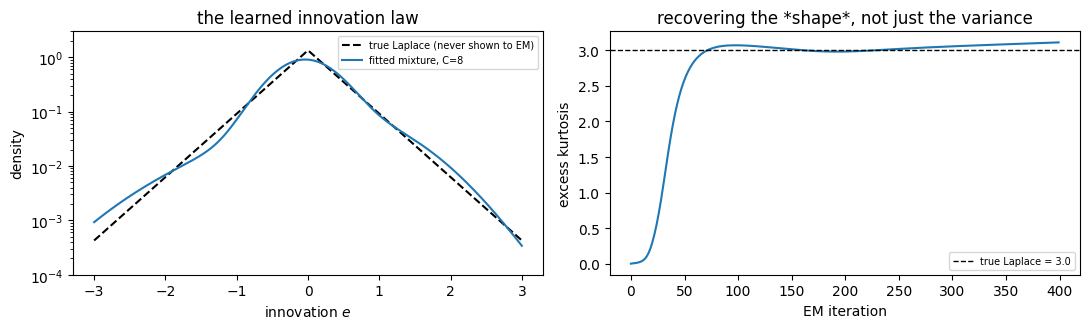

In [9]:
e = np.linspace(-3, 3, 400)
b = np.sqrt((1 - RHO_TRUE ** 2) / 2)
true_density = np.exp(-np.abs(e) / b) / (2 * b)
fitted_density = (fit_pi[:, None] * np.exp(-0.5 * (e[None] - fit_mu[:, None]) ** 2
                  / fit_s2[:, None]) / np.sqrt(2 * np.pi * fit_s2[:, None])).sum(0)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].semilogy(e, true_density, "k--", lw=1.5, label="true Laplace (never shown to EM)")
ax[0].semilogy(e, fitted_density, lw=1.5, label=f"fitted mixture, C={len(fit_pi)}")
ax[0].set_ylim(1e-4, 3); ax[0].set_xlabel("innovation $e$"); ax[0].set_ylabel("density")
ax[0].legend(fontsize=7); ax[0].set_title("the learned innovation law")
ax[1].plot(hist_mix[:, 3], lw=1.5)
ax[1].axhline(3.0, color="k", ls="--", lw=1, label="true Laplace = 3.0")
ax[1].set_xlabel("EM iteration"); ax[1].set_ylabel("excess kurtosis")
ax[1].legend(fontsize=7); ax[1].set_title("recovering the *shape*, not just the variance")
plt.tight_layout(); plt.show()

The fitted density tracks the Laplace over three decades. It rounds off the cusp at the origin —
a finite Gaussian mixture cannot produce a kink — but it finds the heavy tails, and the excess
kurtosis climbs from $0$, its Gaussian starting point, to roughly the true value of $3$.

Two honest caveats, because a single number here is easy to over-read. The estimate of a *shape*
is high-variance: repeating this with different data draws at the same settings gives values
spread over roughly $2.4$ to $4.0$, so do not read the third digit, and do not read a single run
as "the method recovers $x\%$". And the answer depends on having enough of everything — the same
code at $256$ chains of $24$ sites with $C=6$ plateaus near $2.1$ instead. That is why this step
gets the larger sample.

## Step 3 — what the learned kernel buys: the score at every noise level, for free

A diffusion model needs the score $\nabla_x \log p_t(x)$ at every $t$ along the sampling
trajectory. Normally that is what the neural network is trained to produce, separately for each
$t$. Here it follows from the kernel by **Tweedie's identity**:

$$\mathbb E[a \mid x] = \text{(posterior mean from BP)}, \qquad
\nabla_x \log p_t(x) = -\frac{x - \alpha_t\, \mathbb E[a\mid x]}{\Delta_t}.$$

The learned object lives on $\mathbb R\times\mathbb R$ and carries **no dependence on $t$
whatsoever**. Fit it once, and you have a denoiser at every noise level — including levels you
never trained on.

Below we compare, at each $t$, the score from our learned kernel against the score you would get
from a Gaussian kernel that is **handed the true $\rho$ and the true innovation variance** and is
wrong only about the *shape*. That is a deliberately demanding baseline: it is an oracle on
everything second-order, while our kernel had to estimate all of it.

In [10]:
def posterior_mean(grid, w, log_K, X, t):
    "E[a_i | x] at every site, from the BP forward-backward marginals."
    n, T = X.shape
    K = np.exp(log_K)
    lu = log_unary(X, t, grid); lik = np.exp(lu - lu.max(axis=2, keepdims=True))
    f = np.empty((n, T, grid.size))
    cur = np.exp(log_prior_site1(grid))[None, :] * lik[:, 0, :]
    f[:, 0] = cur / (cur * w).sum(1)[:, None]
    for i in range(1, T):
        cur = ((f[:, i - 1] * w) @ K.T) * lik[:, i, :]
        f[:, i] = cur / (cur * w).sum(1)[:, None]
    b = np.ones((n, T, grid.size))
    for i in range(T - 2, -1, -1):
        m = (b[:, i + 1] * lik[:, i + 1] * w) @ K
        b[:, i] = m / m.max(axis=1, keepdims=True)
    post = f * b
    post /= (post * w).sum(2, keepdims=True)
    return (post * w * grid).sum(2)

def score_from_mean(X, m, t):
    a, d = alpha_delta(t)
    return -(X - a * m) / d

lK_true = None   # built per t below from the TRUE Laplace kernel, on the grid
def log_K_laplace(rho, q, grid):
    b = np.sqrt(q / 2.0)
    e = grid[:, None] - rho * grid[None, :]
    return -np.abs(e) / b - np.log(2 * b)

lK_fit = log_K_mixture(fit_rho, fit_pi, fit_mu, fit_s2, grid)
lK_tru = log_K_laplace(RHO_TRUE, 1 - RHO_TRUE ** 2, grid)
lK_gau = log_K_gaussian(RHO_TRUE, 1 - RHO_TRUE ** 2, grid)   # right rho, wrong shape

A_test = sample_chains(RHO_TRUE, 128, N_SITES, laplace_innov, np.random.default_rng(9))
print(f"{'t':>6} {'learned kernel':>16} {'Gaussian guess':>16}")
print(f"{'':>6} {'(rel. score err)':>16} {'(rel. score err)':>16}")
for t in (0.05, 0.2, 0.6, 1.2, 2.0):          # 0.05 and 2.0 were never in T_TRAIN
    Xt = noise(A_test, t, np.random.default_rng(10))
    s_true = score_from_mean(Xt, posterior_mean(grid, w, lK_tru, Xt, t), t)
    s_fit  = score_from_mean(Xt, posterior_mean(grid, w, lK_fit, Xt, t), t)
    s_gau  = score_from_mean(Xt, posterior_mean(grid, w, lK_gau, Xt, t), t)
    rel = lambda s: np.linalg.norm(s - s_true) / np.linalg.norm(s_true)
    star = "  <- never trained at this t" if t in (0.05, 2.0) else ""
    print(f"{t:6.2f} {rel(s_fit):16.4f} {rel(s_gau):16.4f}{star}")

     t   learned kernel   Gaussian guess
       (rel. score err) (rel. score err)
  0.05           0.0996           0.2618  <- never trained at this t
  0.20           0.0311           0.0905
  0.60           0.0111           0.0212
  1.20           0.0046           0.0050
  2.00           0.0018           0.0005  <- never trained at this t


Read that table carefully, because it does **not** say "our kernel wins". It says something more
useful.

At **low** noise the learned kernel is decisively better — about $2.6\times$ at $t=0.05$ and
$2.9\times$ at $t=0.2$ — and $t=0.05$ appeared in no training group at all. The advantage narrows
as $t$ grows ($1.9\times$ at $t=0.6$, a dead heat at $t=1.2$) and finally **reverses**: at $t=2$
the oracle Gaussian is several times better.

Both halves are the same fact. As $t$ grows the channel washes out everything except second-order
structure, and there the Gaussian was simply *given* the right answer. As $t$ shrinks the posterior
begins to resolve the actual shape of the innovation law, and no Gaussian can represent a Laplace
however well its variance is tuned. **The shape only pays where the shape is still visible.**

That is worth internalising before reading any comparison in this project: **which method looks
better depends on the noise level you evaluate at**, and a single number averaged over a schedule
can hide a reversal like this one. It also explains the protocol choice above — the low-$t$ groups
are doing the work of identifying $\varphi$.

The genuine payoff remains: one fit, no $t$ anywhere in the learned object, a usable score at
every level including unseen ones.

## Step 4 — a warning worth more than any of the numbers above

Look again at the kurtosis trace in Step 2, and compare it with $\rho$:

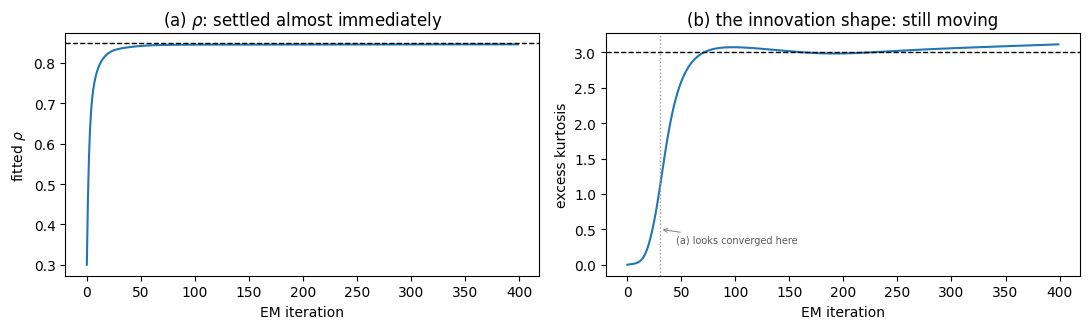

iteration   10:  rho 0.7834   excess kurtosis 0.033
iteration   30:  rho 0.8353   excess kurtosis 1.080
iteration   60:  rho 0.8438   excess kurtosis 2.865
iteration  120:  rho 0.8456   excess kurtosis 3.056
iteration  250:  rho 0.8460   excess kurtosis 3.021
iteration  399:  rho 0.8462   excess kurtosis 3.113


In [11]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot(hist_mix[:, 0], lw=1.5)
ax[0].axhline(RHO_TRUE, color="k", ls="--", lw=1)
ax[0].set_title(r"(a) $\rho$: settled almost immediately")
ax[1].plot(hist_mix[:, 3], lw=1.5)
ax[1].axhline(3.0, color="k", ls="--", lw=1)
ax[1].axvline(30, color="0.6", ls=":", lw=1)
ax[1].annotate("(a) looks converged here", xy=(30, 0.5), xytext=(45, 0.3), fontsize=7,
               color="0.35", arrowprops=dict(arrowstyle="->", color="0.5", lw=0.7))
ax[1].set_title("(b) the innovation shape: still moving")
for a_ in ax: a_.set_xlabel("EM iteration")
ax[0].set_ylabel(r"fitted $\rho$"); ax[1].set_ylabel("excess kurtosis")
plt.tight_layout(); plt.show()

for it in (10, 30, 60, 120, 250, 399):
    print(f"iteration {it:4d}:  rho {hist_mix[it,0]:.4f}   excess kurtosis {hist_mix[it,3]:.3f}")

**The two panels are the same run, on the same axis.** By iteration 30 $\rho$ is within $0.011$ of
where it finally lands and looks settled. At that same iteration the excess kurtosis is $1.08$ —
about **a third** of its final value. Had we stopped where panel (a) looks converged, we would
have reported a kernel missing two thirds of the non-Gaussianity, with nothing on screen to
suggest anything was wrong.

This is not a curiosity. In this project the same trap produced three separate false findings, at
three different iteration budgets — a spurious pointwise-versus-generative dissociation, a
spurious "capacity" effect, and a spurious cost of the noising channel. In each case the natural
diagnostic to plot is $\rho$, and a flat $\rho$ trace certifies a kernel that is nowhere near
converged.

The reason it is so convincing is worth spelling out. Stopping early does not add symmetric noise.
Whatever converges *slower* looks systematically *worse*, so an under-iterated run produces a
clean, one-sided *deficit* — which is exactly what a real effect looks like.

Two mechanisms compound here, and they are worth keeping apart:

* the shape is slow **even with no noise at all**, on clean chains where nothing is missing; that
  belongs to the mixture's inner latent label, not to the observation model;
* the channel then slows everything further, which is the classical missing-information effect
  (Dempster–Laird–Rubin): EM's convergence rate is governed by the fraction of the information the
  observation process destroys, and this channel destroys far more shape information than
  correlation information.

The practical rule: **a fixed iteration budget compares convergence rates, not estimators.** Judge
convergence on the slowest coordinate, never the fastest — and prefer a convergence criterion to a
fixed count. See `audit/AUDIT_NOTE.md` in this repository for the full diagnosis.

## Step 5 — check the from-scratch code against the repository

Everything above was written independently in this notebook. The repository has a tested
implementation of the same algorithm (`src/em.py`, `src/kernels.py`, covered by 220 tests). If the
two disagree, at least one is wrong.

In [12]:
import sys
sys.path.insert(0, "..")
from src.bp_grid import make_grid as repo_make_grid
from src.em import e_step_multi, fit_em
from src.kernels import GaussianAR1Kernel
from src.noising import alpha_delta as repo_alpha_delta

g_r, w_r = repo_make_grid(8.0, 161)
print(f"grids identical: {np.allclose(g_r, grid) and np.allclose(w_r, w)}")

# same E-step: our log-evidence against the repo's, at the same theta
rho_t, q_t = 0.62, 0.44
a_, d_ = repo_alpha_delta(0.4)
ours, _ = bp(grid, w, log_K_gaussian(rho_t, q_t, grid), X_g, 0.4)
theirs = e_step_multi(g_r, w_r, GaussianAR1Kernel(rho_t, q_t).log_transition_matrix(g_r),
                      [(X_g, a_, d_)]).log_evidence
print(f"log-evidence  ours {ours:.6f}   repo {theirs:.6f}   diff {abs(ours-theirs):.2e}")

# same fitted parameters after the same number of EM iterations
rho_o, q_o, _ = em_gaussian(X_g, 0.4, grid, w, 0.2, 0.8, n_iter=40)
k_repo, _ = fit_em(GaussianAR1Kernel(0.2, 0.8), g_r, w_r, [(X_g, a_, d_)], n_iters=40)
print(f"fitted rho    ours {rho_o:.6f}   repo {k_repo.rho:.6f}   diff {abs(rho_o-k_repo.rho):.2e}")
print(f"fitted q      ours {q_o:.6f}   repo {k_repo.q:.6f}   diff {abs(q_o-k_repo.q):.2e}")

grids identical: True
log-evidence  ours -8253.732905   repo -8253.732905   diff 1.82e-12


fitted rho    ours 0.833453   repo 0.833453   diff 1.58e-14
fitted q      ours 0.335793   repo 0.335793   diff 4.20e-14


## What to take away

1. **Noising a Markov chain leaves a Markov chain.** The channel adds one unary factor per site
   and no edges, so belief propagation on the posterior is exact — not an approximation. That is
   the single structural fact everything else rests on.
2. **Exact BP gives EM everything it needs**: the exact marginal likelihood as an objective, and
   the exact pairwise posteriors as sufficient statistics.
3. **The kernel is genuinely learnable from noised data alone**, from a random start, with the
   likelihood monotone throughout — including the innovation *density*, recovered here for a
   Laplace by a Gaussian mixture that had never seen one.
4. **Fisher's identity makes the gradient route free**: one BP pass gives the gradient of the exact
   marginal likelihood, with no differentiation through the recursion. Where a closed-form M-step
   exists it is better; where it does not, this is how you proceed.
5. **The learned kernel is a model, not a function of $(x,t)$**, so it yields the score at every
   noise level — including levels never trained on.
6. **Watch the slowest coordinate.** $\rho$ converges long before the innovation shape, and a
   fixed iteration budget silently compares convergence rates instead of estimators.